In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [2]:
df["Gift Type"].unique()

<StringArray>
['Monetary Gift', 'Contract', 'Real Estate']
Length: 3, dtype: str

There are 3 different kinds of gift types: monetary gift, a contract, and real estate. The monetary gift and the contract are essentially cash, or cash in exchange for labor. The other kind of gift is land or property with real estate.

## Groupby

In [13]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)


Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
                   ...    
IRAN                    80
ST. LUCIA               50
CROATIA                 26
SLOVAKIA                20
ERITREA                  3
Name: Foreign Gift Amount, Length: 155, dtype: int64

In [21]:
df.groupby("Country of Giftor").size().sort_values(ascending=False)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
                   ... 
ST. LUCIA             1
TOKELAU               1
SLOVAKIA              1
ST. KITTS-NEVIS       1
TUNISIA               1
Length: 155, dtype: int64

In [22]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].mean().sort_values(ascending=False)

Country of Giftor
BERMUDA      7.688837e+06
ECUADOR      3.985140e+06
QATAR        3.905109e+06
ANTIGUA      3.435545e+06
JERSEY       3.064589e+06
                 ...     
ST. LUCIA    5.000000e+01
IRAN         4.000000e+01
CROATIA      2.600000e+01
SLOVAKIA     2.000000e+01
ERITREA      3.000000e+00
Name: Foreign Gift Amount, Length: 155, dtype: float64

## Ordering by institution

In [23]:
df.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
                                            ...    
Jacksonville State University                250000
Metropolitan State University                235439
University of California, Merced             182514
University of Central Oklahoma               160288
University of Jamestown                         500
Name: Foreign Gift Amount, Length: 318, dtype: int64

In [24]:
df.groupby("Institution Name").size().sort_values(ascending=False)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
                                               ... 
Washington Adventist University                   1
Western Oregon University                         1
Wesleyan College                                  1
Wayne State University                            1
Yeshiva University                                1
Length: 318, dtype: int64

4. Carnegie Melon University receives the most money in total.
5. University of California, Los Angeles receives the greatest number of gifts by count.

In [38]:
top_20 = df.groupby("Institution Name").size().sort_values(ascending=False).head(20).reset_index(name="Number of Gifts Received")
top_20 # had to look up how to get the series to a df, without reset_index, it returns a series which cannot be plotted

,Institution Name,Number of Gifts Received
0,"University of California, Los Angeles",3916
1,California Institute of Technology,2502
2,Columbia University in the City of New York,1127
3,Ohio State University (The),1014
4,Johns Hopkins University,899
5,University of Michigan - Ann Arbor,715
6,Stanford University,668
7,Cornell University,653
8,University of Pennsylvania,625
9,Massachusetts Institute of Technology,582


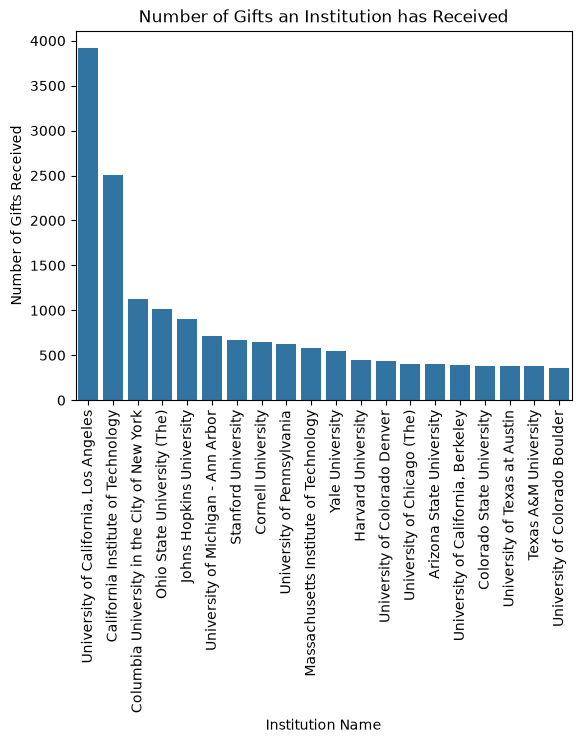

In [45]:
sns.barplot(data=top_20, x="Institution Name", y="Number of Gifts Received")
plt.title("Number of Gifts an Institution has Received")
plt.xticks(rotation = 90)
plt.show()

## Comparing summary statistics